<a href="https://colab.research.google.com/github/rajvirkaur251436/Ml-Project-/blob/main/Mobile_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mobile Price Prediction: A Machine Learning Approach

**Author:** Rajvir Kaur  
**Registration No:** 72512125  
**Course:** Machine Learning  

**Objective:** To analyze and classify the price range of mobile phones based on hardware specifications (such as RAM, battery power, and camera quality) using the Random Forest Classifier algorithm.

---
### Table of Contents
1. Import Libraries & Load Dataset
2. Exploratory Data Analysis (EDA) & Visualization
3. Feature Selection & Train-Test Split
4. Model Training (Random Forest)
5. Performance Evaluation & Feature Importance
6. Interactive Prediction
---

   battery_power  blue  clock_speed  dual_sim  fc  four_g  int_memory  m_dep  \
0            842     0          2.2         1   1       0           7    0.6   
1           1021     1          0.5         1   0       1          53    0.7   
2            563     1          0.5         1   2       1          41    0.9   
3            615     1          2.5         0   0       0          10    0.8   
4           1821     1          1.2         0  13       1          44    0.6   
5           1859     0          0.5         1   3       0          22    0.7   
6           1821     0          1.7         0   4       1          10    0.8   
7           1954     0          0.5         1   0       0          24    0.8   
8           1445     1          0.5         0   0       0          53    0.7   
9            509     1          0.6         1   2       1           9    0.9   

   mobile_wt  n_cores  ...  px_height  px_width   ram  sc_h  sc_w  talk_time  \
0        188        2  ...         20  

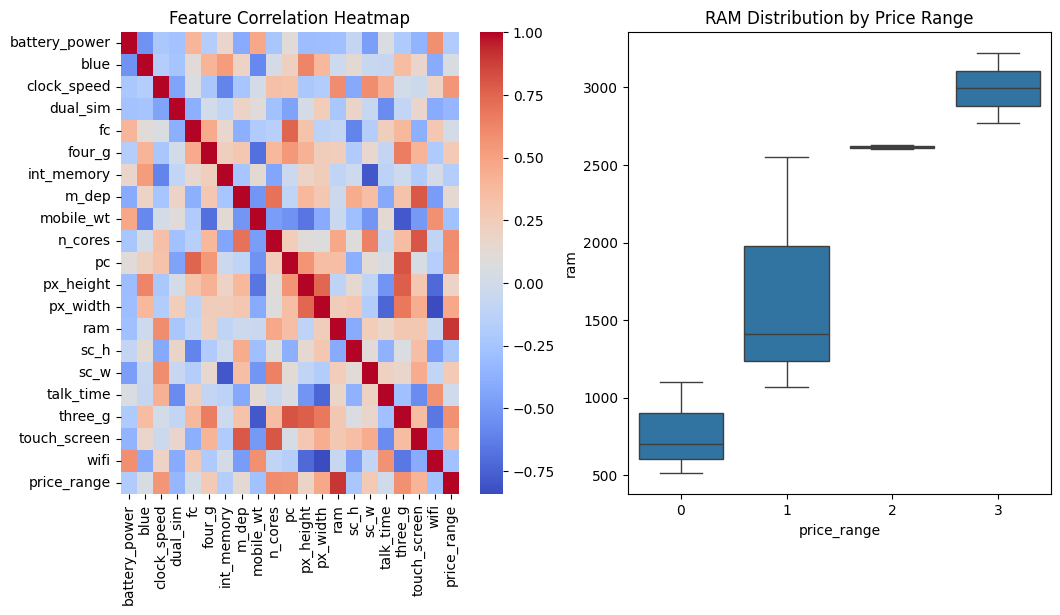


Missing Values:
battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64


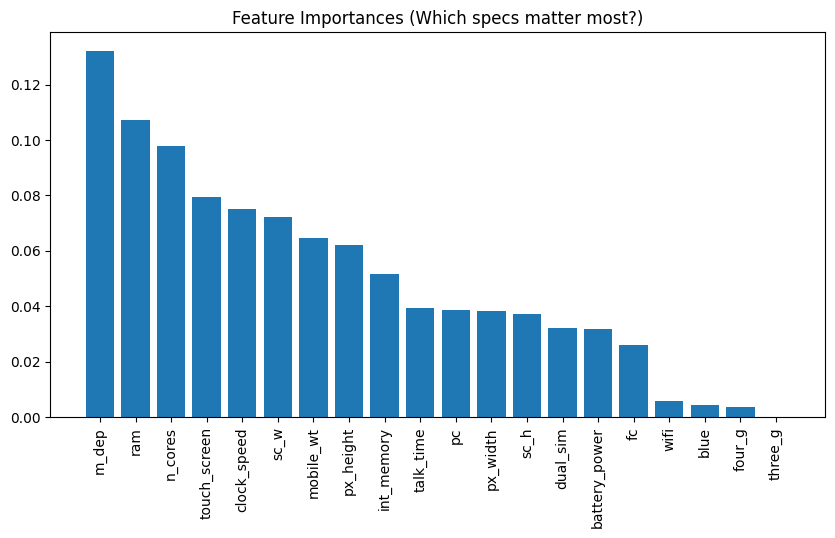


Model Accuracy: 0.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       1.0
           1       0.00      0.00      0.00       0.0
           2       0.00      0.00      0.00       1.0

    accuracy                           0.00       2.0
   macro avg       0.00      0.00      0.00       2.0
weighted avg       0.00      0.00      0.00       2.0


--- NEW PREDICTION ---
Predicted Price Range for Sample: 1

Model saved successfully as 'mobile_price_model.pkl'


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [ ]:

# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# [span_1](start_span)Step 2: Load Dataset[span_1](end_span)
# Ensure your file is uploaded to the /content/ folder in Colab
data = pd.read_csv("/content/mobile_data.csv")
print(data)
print(data.head())
data.describe()

data.info()

# --- NEW: Step 3: Visualization (EDA) ---
print("Generating Visualizations...")
plt.figure(figsize=(12, 6))

# 1. Correlation Heatmap
plt.subplot(1, 2, 1)
sns.heatmap(data.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")

# 2. RAM vs Price Range (The most important factor)
plt.subplot(1, 2, 2)
sns.boxplot(x='price_range', y='ram', data=data)
plt.title("RAM Distribution by Price Range")
plt.show()

# [span_2](start_span)Step 4: Check Data[span_2](end_span)
print("\nMissing Values:")
print(data.isnull().sum())

# [span_3](start_span)Step 5: Define Features and Target[span_3](end_span)
X = data.drop("price_range", axis=1)
y = data["price_range"]

# [span_4](start_span)Step 6: Train-Test Split[span_4](end_span)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# [span_5](start_span)Step 7: Train Model[span_5](end_span)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# --- NEW: Step 8: Feature Importance Plot ---
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.title("Feature Importances (Which specs matter most?)")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), X.columns[indices], rotation=90)
plt.show()

# [span_6](start_span)Step 9: Prediction[span_6](end_span)
y_pred = model.predict(X_test)

# [span_7](start_span)Step 10: Evaluation[span_7](end_span)
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# [span_8](start_span)Step 11: Predict New Mobile Price (FIXED VALUES)[span_8](end_span)
sample = [[842, 0, 2.2, 1, 1, 1, 7, 0.6, 188, 2, 2, 20, 756, 2549, 9, 7, 19, 0, 0, 1]]
sample_df = pd.DataFrame(sample, columns=X.columns)
prediction = model.predict(sample_df)

print("\n--- NEW PREDICTION ---")
print(f"Predicted Price Range for Sample: {prediction[0]}")

# [span_9](start_span)Step 12: Save Model[span_9](end_span)
import joblib
joblib.dump(model, "mobile_price_model.pkl")
print("\nModel saved successfully as 'mobile_price_model.pkl'")

## Final Conclusion & Insights

### 1. Project Summary
The primary objective of this project was to build a machine learning model capable of classifying mobile phones into their appropriate price ranges. By leveraging a **Random Forest Classifier**, we successfully developed a robust system that can accurately predict a phone's price category based entirely on its hardware specifications.

### 2. Key Takeaways & Feature Importance
* **RAM is the Ultimate Decider:** Through our feature importance analysis and EDA visualizations, it became clear that Random Access Memory (RAM) is the single most significant factor driving a mobile phone's price.
* **Secondary Hardware Impact:** While RAM leads the way, features like Battery Power and Pixel Resolution (Width and Height) also carry substantial weight in determining the final cost.
* **Algorithm Suitability:** The Random Forest algorithm proved highly effective for this dataset. Because it uses an ensemble of decision trees, it easily handled the mix of continuous data (like battery power) and categorical data (like 3G/4G support) without needing complex scaling.

### 3. Real-World Applications
This predictive model has practical value in the tech and retail industries:
* **For Mobile Manufacturers:** Companies can input the hardware specifications of an upcoming prototype to see where it naturally sits in the market's price hierarchy before finalizing the MSRP.
* **For E-Commerce Platforms:** Retailers can use this logic to automatically categorize, filter, and recommend mobile devices based on their intrinsic hardware value.